# X-ray Bone Fracture Detection: Data Exploration and Preparation
**Author:** Valeria Garcia Hernandez

## Objective
Explore and understand the x-ray dataset to prepare it for training a CNN model to classify images as fractured or non-fractured. Only original images are used to avoid data leakage, and data augmentation will be applied during training.

In [26]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

In [27]:
random.seed(123)

In [19]:
# load dataset path
data_dir = "data"
original_dir = os.path.join(data_dir, "original")

# extract class names
classes = [n for n in os.listdir(original_dir) if not n.startswith('.')]
print(classes)

['fractured', 'non_fractured']


## Class Distribution

fractured 129
non_fractured 289


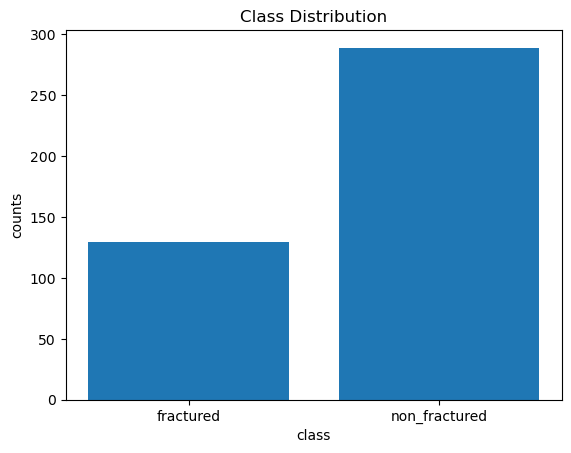

In [20]:
for cls in classes:
    path = os.path.join(original_dir, cls)
    print(cls, len(os.listdir(path)))
    
# class distribution
counts = [len(os.listdir(os.path.join(original_dir, cls))) for cls in classes]
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xlabel("class")
plt.ylabel("counts")
plt.show()

The classes are not evenly distriubuted. The original dataset contains 129 fractured and 289 non-fractured images.

## Display Images

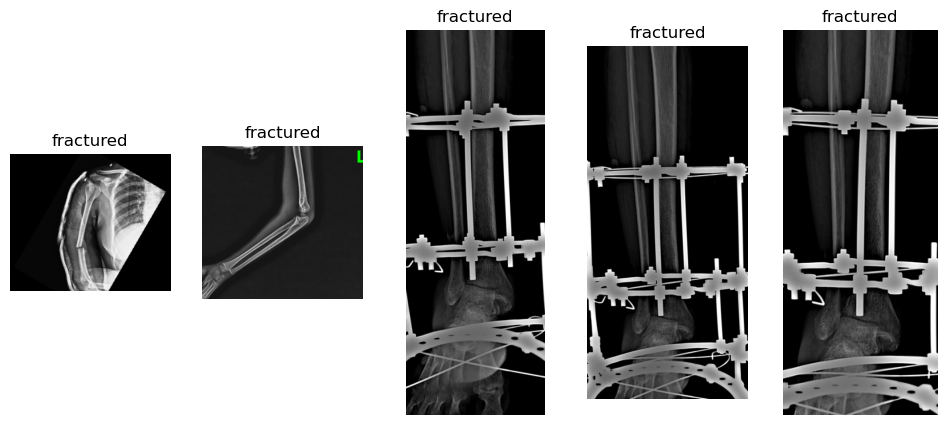

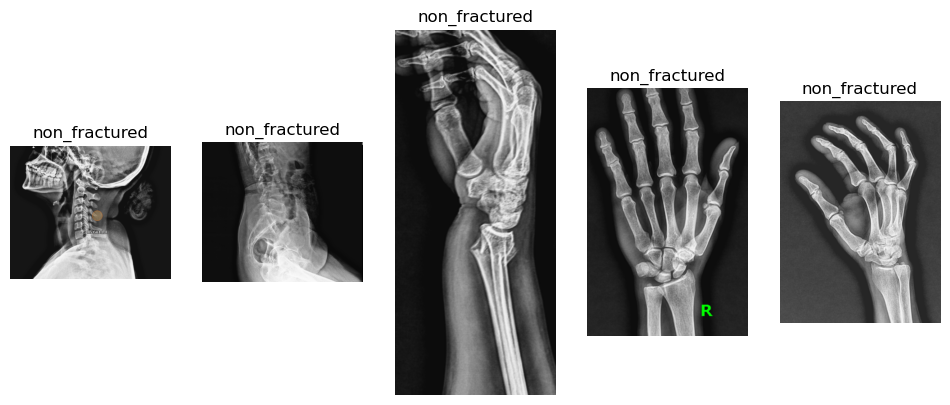

In [21]:
def show_images(class_name, n=5):
    path = os.path.join(original_dir, class_name)
    images = os.listdir(path)[:n]
    
    plt.figure(figsize=(12, 5))
    
    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = Image.open(img_path)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(class_name)
        plt.axis('off')
    plt.show()

for cls in classes:
    show_images(cls)

## Image Properties

In [22]:
# check consistency
img_sizes = []

for cls in classes:
    path = os.path.join(original_dir, cls)
    # sample
    for img_name in os.listdir(path)[:20]:
        img_path = os.path.join(path, img_name)
        img = Image.open(img_path)
        img_sizes.append(img.size)

print(set(img_sizes))

{(420, 561), (450, 428), (494, 373), (368, 520), (697, 610), (333, 285), (418, 530), (220, 545), (231, 389), (495, 365), (147, 600), (460, 435), (290, 661), (193, 481), (213, 649), (497, 292), (255, 600), (307, 436), (252, 585), (207, 318), (312, 551), (301, 606), (258, 513), (313, 565), (321, 468), (709, 638), (279, 270), (543, 450), (210, 585), (246, 276), (218, 540), (282, 302), (405, 583), (433, 599), (419, 606), (154, 232), (237, 550), (253, 250), (274, 602), (392, 606)}


Images are not consisten in size.

In [28]:
mode_counts = Counter()

for cls in classes:
    class_dir = os.path.join(original_dir, cls)
    
    for name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, name)
        
        try:
            img = Image.open(img_path)
            mode_counts[img.mode] += 1
        except:
            print(f"Error with {img_path}")

print(mode_counts)

Counter({'RGBA': 418})


Images are consistent in mode.

## Create Train / Validation / Test Split

In [29]:
# DO NOT RUN AGAIN - dataset already split

#random.seed(123)
#base_dir = "data/processed"
#
#train_dir = os.path.join(base_dir, "train")
#val_dir = os.path.join(base_dir, "val")
#test_dir = os.path.join(base_dir, "test")
#
#for split in [train_dir, val_dir, test_dir]:
#    for cls in classes:
#        os.makedirs(os.path.join(split, cls), exist_ok=True)
#
#train_ratio = 0.7
#val_ratio = 0.15
#test_ratio = 0.15
#
#for cls in classes:
#    src = os.path.join(original_dir, cls)
#    images = os.listdir(src)
#    random.shuffle(images)
#    
#    n = len(images)
#    train_end = int(train_ratio * n)
#    val_end = int((train_ratio + val_ratio) * n)
#    
#    train_imgs = images[:train_end]
#    val_imgs = images[train_end:val_end]
#    test_imgs = images[val_end:]
#    
#    for img in train_imgs:
#        shutil.copy(os.path.join(src, img), os.path.join(train_dir, cls, img))
#        
#    for img in val_imgs:
#        shutil.copy(os.path.join(src, img), os.path.join(val_dir, cls, img))
#        
#    for img in test_imgs:
#        shutil.copy(os.path.join(src, img), os.path.join(test_dir, cls, img))
#print("success")

**Verify split:**

In [30]:
for split_name, split_path in [("train", train_dir), ("val", val_dir), ("test", test_dir)]:
    print(f"\n{split_name} set:")
    for cls in classes:
        count = len(os.listdir(os.path.join(split_path, cls)))
        print(f"{cls}: {count}")


train set:
fractured: 90
non_fractured: 202

val set:
fractured: 19
non_fractured: 43

test set:
fractured: 20
non_fractured: 44


## Additional Observations
- Since the dataset is realtively small, data augmentation is necessary.